In [ ]:
import pandas as pd
from google.colab import drive

# 1️⃣ Mount Google Drive
drive.mount('/content/drive')

# 2️⃣ Tentukan path file di Google Drive
# ⚠️ Ganti path berikut dengan lokasi file kamu di Drive
file_path = '/content/drive/MyDrive/Semester 7/PPW/berita_detik.csv'

# 3️⃣ Baca file (abaikan baris komentar)
df = pd.read_csv(file_path, sep="\t", comment="#", names=["FromNodeId", "ToNodeId"])

# 4️⃣ Tampilkan sebagian data
print("=== 10 Data Teratas ===")
print(df.head(10))  # tampilkan 10 baris pertama

print("\n=== 10 Data Terakhir ===")
print(df.tail(10))  # tampilkan 10 baris terakhir

# 5️⃣ Tampilkan info jumlah data
print("\nJumlah baris (edges):", len(df))
print("Jumlah kolom:", len(df.columns))
print("Ukuran dataset:", df.shape)


Mounted at /content/drive
=== 10 Data Teratas ===
                                          FromNodeId  ToNodeId
0                         id,judul,link,kategori,isi       NaN
1  1,"Alfamart Gelar Donor Darah Serentak di 34 K...       NaN
2  2,Yusril: Presiden Tak Akan Bentuk Tim Investi...       NaN
3  3,Bobby Nasution Wajibkan OPD di Sumut Beri Ke...       NaN
4  4,"Jelang Muktamar X, DPC PPP Se-Jateng Deklar...       NaN
5  5,"Ada Diskon Tiket Whoosh untuk Keberangkatan...       NaN
6  6,"Video: Profil Djamari Chaniago, Jenderal Te...       NaN
7  7,"Jadi Kepala Badan Komunikasi Pemerintah, An...       NaN
8  8,Eropa Percepat Sanksi Energi Rusia di Tengah...       NaN
9  9,Warga Segel Rumah Dapur MBG di Bandung karen...       NaN

=== 10 Data Terakhir ===
                                            FromNodeId  ToNodeId
191  191,Kapan Fenomena Gerhana Terakhir di Tahun 2...       NaN
192  192,"Ipda Kadek Sumerta, Sosok Peduli 100 Peny...       NaN
193  193,"Partner In Crime Juga Diti

In [ ]:
!pip install Sastrawi


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
from google.colab import drive
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# 1️⃣ Hubungkan ke Google Drive
drive.mount('/content/drive')

# 2️⃣ Baca dataset berita
file_path = '/content/drive/MyDrive/Semester 7/PPW/berita_detik.csv'
df = pd.read_csv(file_path)

print("=== Contoh Data ===")
print(df.head(3))

# 3️⃣ Ambil kolom teks (ganti jika nama kolom berbeda)
text_column = "isi"   # pastikan sesuai nama kolom di CSV
titles = df["judul"].astype(str).tolist()
texts = df[text_column].astype(str).tolist()

# 4️⃣ Gunakan stopwords Bahasa Indonesia dari Sastrawi
factory = StopWordRemoverFactory()
stopwords = factory.get_stop_words()

# 5️⃣ TF-IDF dan cosine similarity
print("\n🔄 Menghitung kemiripan antar berita...")
vectorizer = TfidfVectorizer(max_features=5000, stop_words=stopwords)
tfidf_matrix = vectorizer.fit_transform(texts)

similarity_matrix = cosine_similarity(tfidf_matrix)

# 6️⃣ Buat graph dari similarity (threshold = 0.2 biar tidak terlalu padat)
threshold = 0.2
edges = np.where(similarity_matrix > threshold)

G = nx.Graph()
for i, j in zip(edges[0], edges[1]):
    if i != j:
        G.add_edge(i, j, weight=similarity_matrix[i, j])

print(f"\nJumlah node: {G.number_of_nodes()}")
print(f"Jumlah edge: {G.number_of_edges()}")

# 7️⃣ Hitung PageRank
print("\n⚙️ Menghitung PageRank...")
pagerank_scores = nx.pagerank(G, alpha=0.85)

# 8️⃣ Ambil 10 berita dengan skor tertinggi
top_nodes = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:10]

print("\n🏆 Top 10 Berita dengan PageRank Tertinggi:")
for i, (idx, score) in enumerate(top_nodes, 1):
    print(f"{i}. {titles[idx]} — Skor: {score:.6f}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Contoh Data ===
   id                                              judul  \
0   1  Alfamart Gelar Donor Darah Serentak di 34 Kota...   
1   2  Yusril: Presiden Tak Akan Bentuk Tim Investiga...   
2   3  Bobby Nasution Wajibkan OPD di Sumut Beri Kete...   

                                                link kategori  \
0  https://news.detik.com/berita/d-8117096/alfama...     news   
1  https://news.detik.com/berita/d-8117082/yusril...     news   
2  https://news.detik.com/berita/d-8117080/bobby-...     news   

                                                 isi  
0  alfamart kembali menggelar aksi donor darah se...  
1  menteri koordinator bidang hukum, ham, imigras...  
2  gubernur sumatera utara (sumut) bobby nasution...  

🔄 Menghitung kemiripan antar berita...

Jumlah node: 155
Jumlah edge: 400

⚙️ Menghitung PageRank...

🏆 Top 10 Berita dengan Pag

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


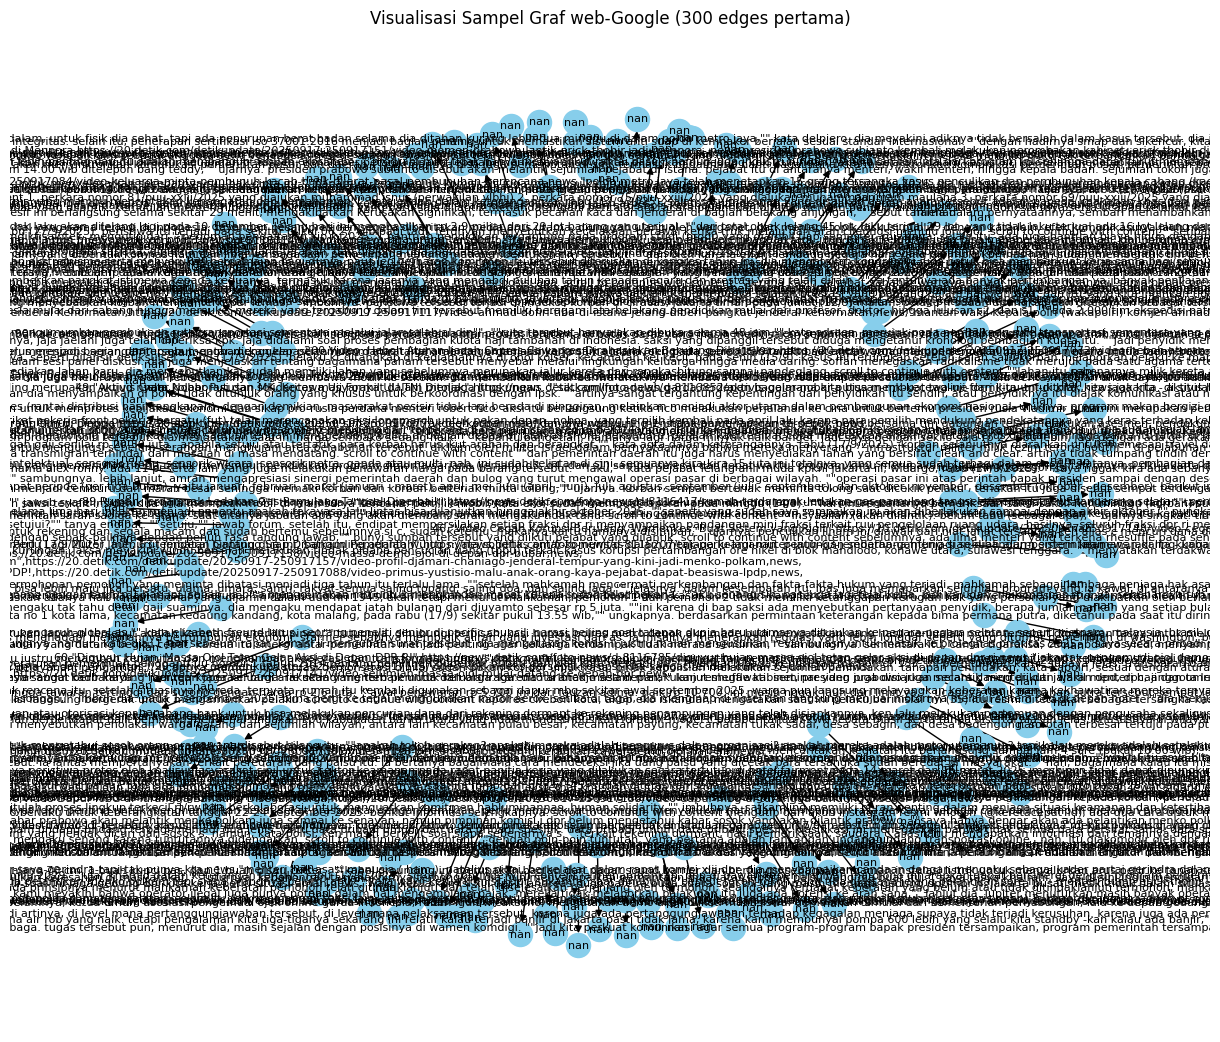

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from google.colab import drive

# 1️⃣ Hubungkan Google Drive
drive.mount('/content/drive')

# 2️⃣ Tentukan path file di Drive
# ⚠️ Ganti path ini sesuai lokasi file kamu di Google Drive
file_path = '/content/drive/MyDrive/Semester 7/PPW/berita_detik.csv'

# 3️⃣ Baca dataset (abaikan baris komentar)
df = pd.read_csv(file_path, sep="\t", comment="#", names=["FromNodeId", "ToNodeId"])

# 4️⃣ Ambil sampel data kecil agar bisa divisualisasikan (contoh: 300 edges pertama)
sample_df = df.head(300)

# 5️⃣ Buat graf berarah
G = nx.DiGraph()
G.add_edges_from(zip(sample_df["FromNodeId"], sample_df["ToNodeId"]))

# 6️⃣ Visualisasikan graf
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42)  # posisi node agar rapi
nx.draw(
    G, pos,
    with_labels=True,
    node_size=300,
    font_size=8,
    arrowsize=10,
    node_color="skyblue"
)
plt.title("Visualisasi Sampel Graf web-Google (300 edges pertama)")
plt.show()


In [ ]:
import pandas as pd
from google.colab import drive

# 1️⃣ Hubungkan ke Google Drive
drive.mount('/content/drive')

# 2️⃣ Tentukan path file di Drive
# ⚠️ Ganti path ini sesuai lokasi file kamu di Google Drive
file_path = '/content/drive/MyDrive/Semester 7/PPW/berita_detik.csv'

# 3️⃣ Baca dataset (abaikan baris komentar)
df = pd.read_csv(file_path, sep="\t", comment="#", names=["FromNodeId", "ToNodeId"])

# 4️⃣ Gabungkan semua node (asal & tujuan), lalu ambil yang unik
unique_ids = pd.unique(df[['FromNodeId', 'ToNodeId']].values.ravel('K'))

# 5️⃣ Tampilkan sebagian ID biar tidak terlalu panjang
print("=== 20 Node ID pertama ===")
print(unique_ids[:20])

# 6️⃣ Tampilkan jumlah total ID unik
print("\nJumlah total node unik:", len(unique_ids))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== 20 Node ID pertama ===
['id,judul,link,kategori,isi'
 '1,"Alfamart Gelar Donor Darah Serentak di 34 Kota, Target 26 Ribu Kantong",https://news.detik.com/berita/d-8117096/alfamart-gelar-donor-darah-serentak-di-34-kota-target-26-ribu-kantong,news,"alfamart kembali menggelar aksi donor darah serentak di 34 kota/kabupaten selama satu minggu di september 2025 dalam program sehati \'setetes darah untuk pertiwi\'. dari kegiatan sosial ini, alfamart menargetkan terkumpul 26.000 kantong darah untuk membantu memenuhi stok palang merah indonesia (pmi). ""ini adalah salah satu kontribusi alfamart untuk membantu pasien yang membutuhkan transfusi darah. dengan menggandeng pmi di 34 daerah, kami berharap 26 ribu kantong darah dapat tercapai dan tersalurkan kepada yang membutuhkan,"" kata corporate affairs director alfamart solihin, dalam keterangan tertulis, rabu (17/9/